# Epstein Files Network Influence Pipeline


**Problem statement:** Identify which individuals are most structurally influential in Epstein file records by modeling name co-occurrence as a network and evaluating which centrality patterns remain stable across resampled document sets.

This notebook is the analysis and visualization pipeline for the project. It starts by querying the MongoDB document database into a dataframe, prepares the extracted names for analysis, builds a co-occurrence network, computes centrality metrics, uses bootstrap resampling to test the stability of the rankings, and produces a final visualization.

The goal is not to prove real-world influence. The goal is to identify structural influence within this document collection. In this project, an individual is treated as structurally influential if they repeatedly appear in records with many other named individuals and remain highly ranked when the document set is resampled.


## Analysis Rationale

The refined problem concerns the relationships between people in documents, so I implemented a network model. Each person is represented as a node. If two people are mentioned in the same document, an edge is placed between them. The edge weight counts how many documents contain that pair.

This approach fits the document model because each MongoDB document represents one email or file record with extracted metadata fields, including people mentioned. Instead of analyzing each document independently, the pipeline uses the document collection to create a secondary structure: a person-to-person co-occurrence network.

I use weighted degree as the main influence measure for ease of interpretation. An individual has a higher weighted degree when they co-occur frequently with many other people. I also compute degree centrality and PageRank as additional model-based network metrics that help to compare frequency-based influence with broader graph position.

The concept I took from previous ML classes is bootstrapping. I use bootstrapping to resample documents with replacement, rebuild the network many times, and test whether the same people remain central across slightly different versions of the dataset. This helps quantify uncertainty in the ranking rather than relying on one single network result.


## 1. Imports and Setup

This section imports the libraries used for database access, data preparation, network modeling, bootstrapping, and visualization. Logging is included so database and pipeline errors are recorded instead of silently failing.


In [1]:
import os
import itertools
import logging
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from dotenv import load_dotenv
from pymongo import MongoClient
from pymongo.errors import PyMongoError

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

logging.basicConfig(
    filename="pipeline.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

load_dotenv()


True

## 2. Query MongoDB into a DataFrame

The first required pipeline step is to query MongoDB and place the document records into a dataframe. The database credentials are read from environment variables so that passwords are not stored in the notebook or GitHub repository.


In [2]:
def load_email_documents():
    """Load Epstein email/file records from MongoDB into a pandas DataFrame."""
    mongo_user = os.getenv("MONGO_USER")
    mongo_pass = os.getenv("MONGO_PASS")
    mongo_cluster = os.getenv("MONGO_CLUSTER")

    if not all([mongo_user, mongo_pass, mongo_cluster]):
        raise ValueError(
            "Missing MongoDB credentials. Set MONGO_USER, MONGO_PASS, and MONGO_CLUSTER in a .env file."
        )

    mongo_uri = (
        f"mongodb+srv://{mongo_user}:{mongo_pass}@{mongo_cluster}/"
        "?retryWrites=true&w=majority"
    )

    try:
        client = MongoClient(mongo_uri)
        collection = client["epstein_db"]["emails"]
        records = list(collection.find({}))
        logging.info("Loaded %s records from MongoDB.", len(records))
        return pd.DataFrame(records)
    except PyMongoError as err:
        logging.exception("MongoDB query failed.")
        raise err

raw_df = load_email_documents()
raw_df.shape


(2322, 35)

## 3. Data Preparation

Only fields relevant to the problem are kept. The most important field for the network model is `people_mentioned`, because it provides the extracted names used to create co-occurrence edges. Text fields are retained for context and for the supporting text model.


In [3]:
relevant_columns = [
    "_id", "document_id", "email_text", "subject", "date",
    "people_mentioned", "participant_names", "organizations", "locations",
    "primary_topic", "tone", "evidence_strength",
    "participant_count", "attachment_count", "url_count",
]

available_columns = [col for col in relevant_columns if col in raw_df.columns]
df = raw_df[available_columns].copy()

for col in ["email_text", "subject", "primary_topic", "tone", "evidence_strength"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown").astype(str).str.strip()

for col in ["participant_count", "attachment_count", "url_count"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

if "email_text" in df.columns:
    df["email_length"] = df["email_text"].str.len()
    df["word_count"] = df["email_text"].str.split().str.len()

# Remove records without usable text for analysis.
df = df[df.get("email_text", "") != ""].copy()

df.shape


(2322, 17)

### Name Cleaning Rationale

Names are cleaned before the network is built. I remove blank values, one-word strings, duplicates within a document, and generic labels that are not useful as people nodes. Duplicates within the same document are removed because the network represents whether two people co-occurred in a document, not how many times a name was repeated inside that same document.


In [4]:
GENERIC_NAME_VALUES = {
    "unknown", "none", "nan", "redacted", "n/a", "email", "image", "attachment",
}

def clean_name_list(value):
    """Return a sorted list of unique, usable person names from one document field."""
    if not isinstance(value, list):
        return []

    cleaned = []
    for name in value:
        if not isinstance(name, str):
            continue
        name = " ".join(name.strip().split())
        if not name or name.lower() in GENERIC_NAME_VALUES:
            continue
        if len(name.split()) < 2:
            continue
        cleaned.append(name)

    return sorted(set(cleaned))

df["people_clean"] = df["people_mentioned"].apply(clean_name_list)
network_df = df[df["people_clean"].str.len() >= 2].copy()
docs = network_df["people_clean"].tolist()

print("Documents in dataframe:", len(df))
print("Documents usable for network:", len(docs))
print("Unique cleaned people:", len(set(itertools.chain.from_iterable(docs))))


Documents in dataframe: 2322
Documents usable for network: 2116
Unique cleaned people: 3931


## 4. Supporting Text Model

This short modeling step uses TF-IDF and KMeans to group records by text similarity. This is not the main solution to the influence problem. It is included as a supporting model to give context for the document collection and to satisfy the project requirement that the pipeline implement a model.

The main analytical model is the co-occurrence network, but the text model helps check whether the records contain different kinds of document contexts. This matters because centrality may be affected by what kinds of records dominate the dataset.


In [5]:
if "email_text" in network_df.columns and len(network_df) >= 3:
    vectorizer = TfidfVectorizer(stop_words="english", max_features=500, min_df=2)
    X_text = vectorizer.fit_transform(network_df["email_text"])

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    network_df["text_cluster"] = kmeans.fit_predict(X_text)

    cluster_summary = (
        network_df.groupby("text_cluster")
        .agg(
            document_count=("email_text", "count"),
            avg_word_count=("word_count", "mean"),
            avg_people_per_doc=("people_clean", lambda x: np.mean([len(v) for v in x]))
        )
        .round(2)
    )

    display(cluster_summary)
else:
    print("Not enough text records for KMeans clustering.")


,document_count,avg_word_count,avg_people_per_doc
text_cluster,,,
0,107,364.83,3.67
1,1027,1165.67,9.96
2,982,461.83,3.92


## 5. Build the Name Co-occurrence Network

The co-occurrence graph is the main model used to solve the problem. Each cleaned person name becomes a node. Two names receive an edge when they appear in the same document. Repeated co-occurrence across documents increases the edge weight.


In [6]:
def build_cooccurrence_graph(doc_name_lists, min_edge_weight=1):
    """Build a weighted undirected graph from lists of people mentioned per document."""
    edge_counter = Counter()
    node_counter = Counter()

    for names in doc_name_lists:
        unique_names = sorted(set(names))
        for name in unique_names:
            node_counter[name] += 1
        for person_a, person_b in itertools.combinations(unique_names, 2):
            edge_counter[(person_a, person_b)] += 1

    graph = nx.Graph()
    for name, count in node_counter.items():
        graph.add_node(name, document_frequency=count)
    for (person_a, person_b), weight in edge_counter.items():
        if weight >= min_edge_weight:
            graph.add_edge(person_a, person_b, weight=weight)
    return graph

G = build_cooccurrence_graph(docs)
print("Network nodes:", G.number_of_nodes())
print("Network edges:", G.number_of_edges())


Network nodes: 3931
Network edges: 90281


## 6. Compute Centrality Metrics

The centrality table ranks individuals by several network measures:

- `document_frequency`: number of documents where the person appears.
- `weighted_degree`: total weighted co-occurrence strength with other people.
- `degree_centrality`: share of other people this person is connected to.
- `pagerank`: graph-based centrality that gives more weight to connections with other central people.

Weighted degree is used as the primary metric because it directly matches the problem: structurally influential people should repeatedly co-occur with many other named individuals across the records.


In [7]:
def compute_influence_metrics(graph):
    """Compute centrality metrics for each person in the co-occurrence graph."""
    if graph.number_of_nodes() == 0:
        return pd.DataFrame()

    weighted_degree = dict(graph.degree(weight="weight"))
    degree_centrality = nx.degree_centrality(graph)
    pagerank = nx.pagerank(graph, weight="weight")

    metrics = pd.DataFrame({
        "name": list(graph.nodes()),
        "document_frequency": [graph.nodes[n].get("document_frequency", 0) for n in graph.nodes()],
        "weighted_degree": [weighted_degree.get(n, 0) for n in graph.nodes()],
        "degree_centrality": [degree_centrality.get(n, 0) for n in graph.nodes()],
        "pagerank": [pagerank.get(n, 0) for n in graph.nodes()],
    })
    return metrics.sort_values("weighted_degree", ascending=False).reset_index(drop=True)

influence_df = compute_influence_metrics(G)
influence_df.head(15)


,name,document_frequency,weighted_degree,degree_centrality,pagerank
0,Jeffrey Epstein,1750,9646,0.679898,0.040331
1,Donald Trump,546,2784,0.260560,0.011299
2,Bill Clinton,259,2778,0.209669,0.008653
3,Prince Andrew,107,1391,0.087532,0.004055
4,Ghislaine Maxwell,96,1113,0.067430,0.003217
5,Barack Obama,87,1095,0.158524,0.004749
6,Larry Summers,100,1066,0.102799,0.003689
7,Woody Allen,47,1038,0.130534,0.002383
8,Bill Gates,51,1022,0.079135,0.002984
9,Darren Indyke,123,904,0.076590,0.003372


## 7. Bootstrap Resampling for Stability

This is the uncertainty and stability step. The pipeline repeatedly resamples the document set with replacement. For each bootstrap sample, it rebuilds the co-occurrence network and recomputes weighted degree.

I included this because bootstrapping is a concept I learned in previous classes. It is useful here because the dataset is not a perfect record of all possible communications. If a person only looks central in one exact dataset but falls away when the documents are resampled, that ranking is less stable. If a person remains highly ranked across bootstrap samples, the centrality pattern is more reliable within this dataset.


In [8]:
def bootstrap_centrality(doc_name_lists, n_boot=300, metric="weighted_degree", random_state=42):
    """Resample documents with replacement and recompute centrality for each sample."""
    rng = np.random.default_rng(random_state)
    n_docs = len(doc_name_lists)
    results = []

    for bootstrap_iter in range(n_boot):
        sample_idx = rng.choice(n_docs, size=n_docs, replace=True)
        sampled_docs = [doc_name_lists[i] for i in sample_idx]
        boot_graph = build_cooccurrence_graph(sampled_docs)
        boot_metrics = compute_influence_metrics(boot_graph)

        if metric not in boot_metrics.columns:
            raise ValueError(f"Metric {metric} not found in centrality table.")

        boot_metrics = boot_metrics[["name", metric]].copy()
        boot_metrics["bootstrap_iter"] = bootstrap_iter
        results.append(boot_metrics)

    return pd.concat(results, ignore_index=True)

def summarize_bootstrap_results(boot_df, metric="weighted_degree"):
    """Summarize bootstrap centrality estimates by person."""
    summary = (
        boot_df.groupby("name")[metric]
        .agg(
            mean="mean",
            std="std",
            q025=lambda x: x.quantile(0.025),
            median="median",
            q975=lambda x: x.quantile(0.975),
            times_observed="count"
        )
        .reset_index()
    )
    summary["interval_width"] = summary["q975"] - summary["q025"]
    summary["coefficient_of_variation"] = summary["std"] / summary["mean"].replace(0, np.nan)
    return summary.sort_values("mean", ascending=False).reset_index(drop=True)

boot_df = bootstrap_centrality(docs, n_boot=300, metric="weighted_degree")
boot_summary = summarize_bootstrap_results(boot_df, metric="weighted_degree")
boot_summary.head(15)


,name,mean,std,q025,median,q975,times_observed,interval_width,coefficient_of_variation
0,Jeffrey Epstein,9661.010000,357.204517,8979.450,9666.0,10282.425,300,1302.975,0.036974
1,Bill Clinton,2780.176667,242.778810,2329.975,2784.5,3263.200,300,933.225,0.087325
2,Donald Trump,2779.050000,272.351142,2270.375,2766.0,3278.725,300,1008.350,0.098002
3,Prince Andrew,1392.906667,161.576301,1075.475,1386.5,1742.500,300,667.025,0.115999
4,Ghislaine Maxwell,1119.533333,156.442117,840.000,1107.0,1407.525,300,567.525,0.139739
5,Barack Obama,1094.030000,157.289039,816.700,1086.0,1398.625,300,581.925,0.143770
6,Larry Summers,1076.133333,172.646435,783.325,1069.5,1420.200,300,636.875,0.160432
7,Woody Allen,1021.403333,271.154229,564.600,992.5,1613.000,300,1048.400,0.265472
8,Bill Gates,1008.883333,162.414875,713.475,995.5,1331.300,300,617.825,0.160985
9,Darren Indyke,908.660000,113.186491,697.475,903.0,1125.500,300,428.025,0.124564


## 8. Final Ranking Table

The final table combines the original centrality metrics with the bootstrap stability results. The most stable structurally influential people should have high centrality and relatively narrow bootstrap intervals.


In [9]:
final_rankings = (
    influence_df.merge(
        boot_summary,
        on="name",
        how="left",
        suffixes=("_original", "_bootstrap")
    )
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
)

final_rankings.head(20)


,name,document_frequency,weighted_degree,degree_centrality,pagerank,mean,std,q025,median,q975,times_observed,interval_width,coefficient_of_variation
0,Jeffrey Epstein,1750,9646,0.679898,0.040331,9661.010000,357.204517,8979.450,9666.0,10282.425,300,1302.975,0.036974
1,Bill Clinton,259,2778,0.209669,0.008653,2780.176667,242.778810,2329.975,2784.5,3263.200,300,933.225,0.087325
2,Donald Trump,546,2784,0.260560,0.011299,2779.050000,272.351142,2270.375,2766.0,3278.725,300,1008.350,0.098002
3,Prince Andrew,107,1391,0.087532,0.004055,1392.906667,161.576301,1075.475,1386.5,1742.500,300,667.025,0.115999
4,Ghislaine Maxwell,96,1113,0.067430,0.003217,1119.533333,156.442117,840.000,1107.0,1407.525,300,567.525,0.139739
5,Barack Obama,87,1095,0.158524,0.004749,1094.030000,157.289039,816.700,1086.0,1398.625,300,581.925,0.143770
6,Larry Summers,100,1066,0.102799,0.003689,1076.133333,172.646435,783.325,1069.5,1420.200,300,636.875,0.160432
7,Woody Allen,47,1038,0.130534,0.002383,1021.403333,271.154229,564.600,992.5,1613.000,300,1048.400,0.265472
8,Bill Gates,51,1022,0.079135,0.002984,1008.883333,162.414875,713.475,995.5,1331.300,300,617.825,0.160985
9,Darren Indyke,123,904,0.076590,0.003372,908.660000,113.186491,697.475,903.0,1125.500,300,428.025,0.124564


## 9. Visualization Rationale

The final visualization has two panels.

The left panel shows the co-occurrence network for the top-ranked people. This makes the network model visible: node size represents document frequency, edge width represents co-occurrence strength, and node color represents centrality.

The right panel shows the bootstrap stability of the weighted degree ranking. Each point is the bootstrapped mean weighted degree for one individual, and the error bars show the 95% bootstrap interval. This is the most important visualization for the problem because it shows not only who ranks highly, but whether the ranking remains stable across resampled document sets.


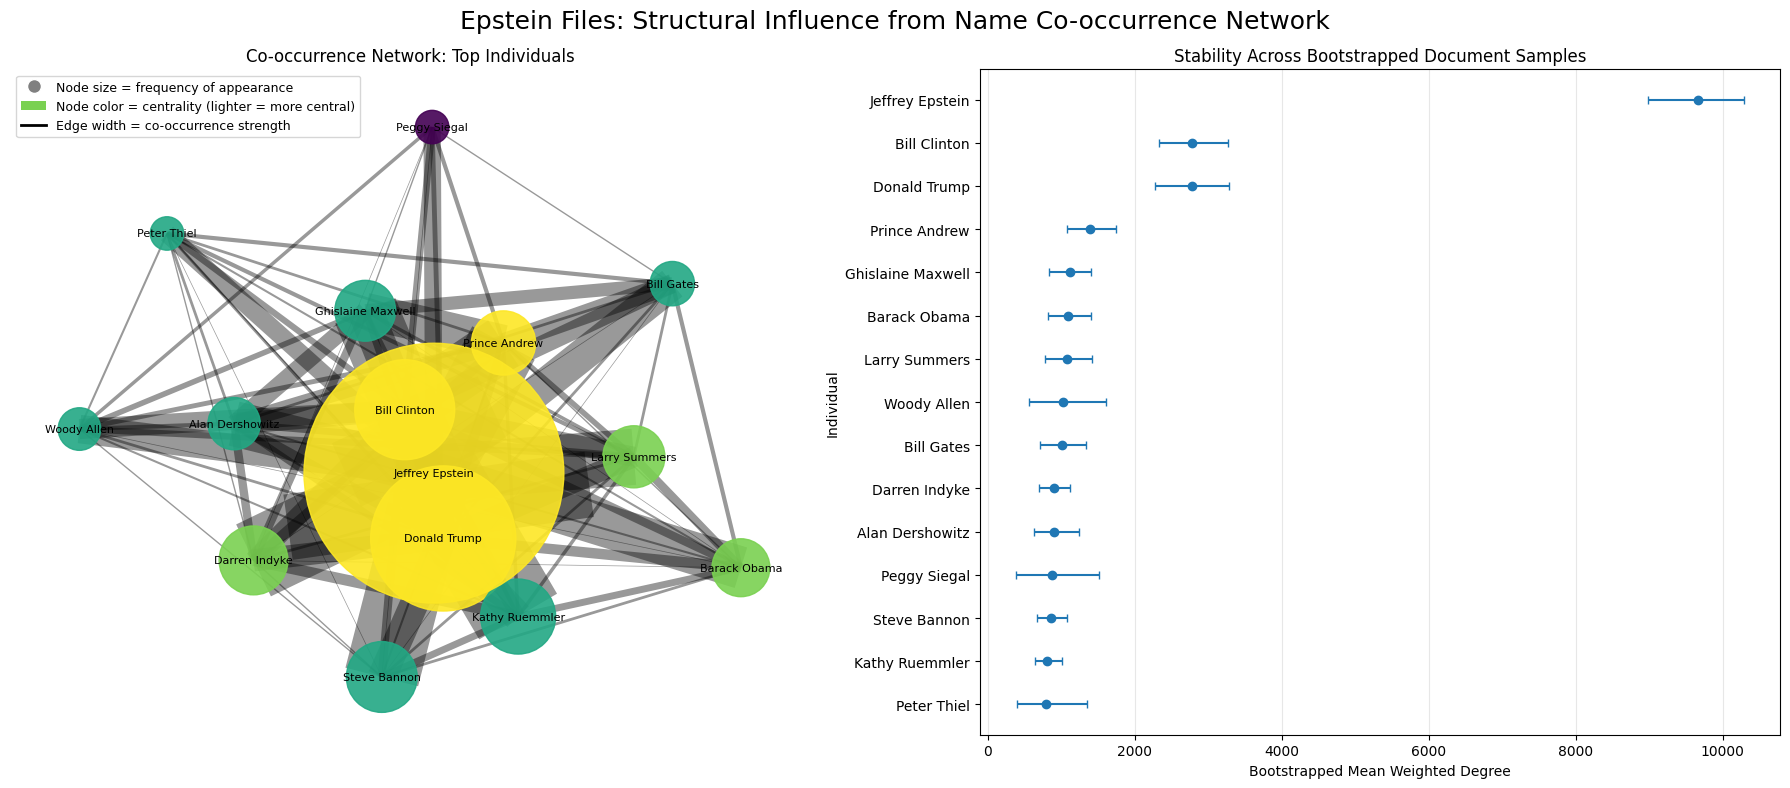

In [12]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_network_and_stability(graph, boot_summary, output_path="epstein_network_and_stability.png", top_n=15):
    """Create the final publication-quality network and bootstrap stability visualization."""
    top_nodes = boot_summary.head(top_n)["name"].tolist()
    graph_plot = graph.subgraph(top_nodes).copy()
    plot_df = boot_summary.head(top_n).sort_values("mean")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    ax = axes[0]
    pos = nx.spring_layout(graph_plot, seed=42, k=1.2)
    node_sizes = [graph_plot.nodes[n].get("document_frequency", 1) * 20 for n in graph_plot.nodes()]
    edge_widths = [graph_plot[u][v].get("weight", 1) * 0.5 for u, v in graph_plot.edges()]
    centrality = nx.degree_centrality(graph_plot)
    node_colors = [centrality[n] for n in graph_plot.nodes()]

    nx.draw_networkx_nodes(graph_plot, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.viridis, alpha=0.9, ax=ax)
    nx.draw_networkx_edges(graph_plot, pos, width=edge_widths, alpha=0.4, ax=ax)
    nx.draw_networkx_labels(graph_plot, pos, font_size=8, ax=ax)
    ax.set_title("Co-occurrence Network: Top Individuals")


    # Create custom legend elements
    legend_elements = [

        # Node size meaning
        Line2D([0], [0], marker='o', color='w',
           label='Node size = frequency of appearance',
           markerfacecolor='gray', markersize=10),

        # Node color meaning
        Patch(facecolor=plt.cm.viridis(0.8),
          label='Node color = centrality (lighter = more central)'),

        # Edge width meaning
        Line2D([0], [0], color='black', lw=2,
           label='Edge width = co-occurrence strength'),

    ]

    ax.legend(
        handles=legend_elements,
        loc='upper left',
        frameon=True,
        fontsize=9
    )
    ax.axis("off")

    ax = axes[1]
    ax.errorbar(
        x=plot_df["mean"],
        y=plot_df["name"],
        xerr=[plot_df["mean"] - plot_df["q025"], plot_df["q975"] - plot_df["mean"]],
        fmt="o",
        capsize=3
    )
    ax.set_xlabel("Bootstrapped Mean Weighted Degree")
    ax.set_ylabel("Individual")
    ax.set_title("Stability Across Bootstrapped Document Samples")
    ax.grid(axis="x", alpha=0.3)

    fig.suptitle("Epstein Files: Structural Influence from Name Co-occurrence Network", fontsize=18)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_network_and_stability(G, boot_summary, output_path="epstein_network_and_stability.png", top_n=15)


## 10. Analysis: Solving the Problem

This pipeline turns the document collection of Epstein's emails into a network of name co-occurrences and evaluates which people are central in that network.

The pipeline first queries the MongoDB document database into a dataframe, which connects the analysis directly to the document model dataset. It then cleans the `people_mentioned` metadata so each document contributes a list of usable person names. From those lists, the pipeline builds a weighted undirected graph. In this graph, nodes are individuals, edges are shared document appearances, and edge weights represent repeated co-occurrence across records.

The pipeline identifies structural influence by computing centrality metrics. The most important metric is weighted degree because it measures how strongly each person is connected to others through repeated co-occurrence. Degree centrality and PageRank are included as additional network metrics so the ranking is not based on only one view of graph position.

The pipeline also addresses uncertainty by using bootstrap resampling, which is the concept I carried over from previous classes. Instead of treating one observed network as final, the notebook repeatedly resamples the document set, rebuilds the network, and recomputes centrality. The resulting bootstrap means and 95% intervals show whether high-ranking individuals remain central across resampled document sets.

The final visualization directly supports the solution. The network panel shows the structure of relationships among highly ranked people, while the bootstrap panel shows the stability of their influence rankings. Together, the table and visualization answer the problem: the most structurally influential individuals are the names with high centrality scores whose rankings remain stable under document-level resampling.

The main limitation is that these results only describe structural influence within the released and processed Epstein file records. They should not be interpreted as proof of real-world influence, guilt, or involvement. The results depend on the released document subset and on the quality of the upstream metadata extraction.
